In [1]:
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

from qiskit_algorithms import NumPyMinimumEigensolver
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz

import sys
sys.path.append("../../")
from testing_scripts.qaoa_utils import QAOASolver, evaluate_energy

import numpy as np
import pcbo_utils
from qiskit.quantum_info import SparsePauliOp

In [ ]:
n_qubits = 8
feature_set, feature_to_idx, first_corr_arr, second_corr_arr, third_corr_arr = pcbo_utils.load_features_and_corr_files(f'sampled_{n_qubits}_features_subproblem_1')

pcbo_obj = pcbo_utils.create_three_body_cubo(
    feature_set,
    first_corr_arr,
    second_corr_arr,
    third_corr_arr,
    feature_to_idx,
    select_n_features=4,
)

pubo = {key: float(value) for key, value in pcbo_obj.to_pubo().items()}

In [3]:
def convert_pubo_to_ising(hypergraph: dict) -> list[tuple[str, float]]:
    """Convert a hypergraph dictionary to a list of Pauli strings with weights."""
    n = n_qubits # Number of qubits
    pauli_list = []

    for edge, weight in hypergraph.items():
        if edge:  # Ensure the edge is not empty
            # Create a Pauli string with "I" for all qubits
            paulis = ["I"] * n
            # Replace "I" with "Z" for qubits in the edge
            for node in edge:
                paulis[node] = "Z"
            # Append the reversed Pauli string and weight to the list
            pauli_list.append(("".join(paulis[::-1]), weight))

    return pauli_list

max_cut_paulis = convert_pubo_to_ising(pubo)
cost_hamiltonian = SparsePauliOp.from_list(max_cut_paulis)
paulis,coeffs = cost_hamiltonian.paulis.to_labels(),cost_hamiltonian.coeffs.real
cost_hamiltonian

SparsePauliOp(['IIIIIIIIIZ', 'IIIIIIIIZI', 'IIIIIIIZII', 'IIIIIIZIII', 'IIIIIZIIII', 'IIIIZIIIII', 'IIIZIIIIII', 'IIZIIIIIII', 'IZIIIIIIII', 'ZIIIIIIIII', 'IIIIIIIIZZ', 'IIIIIIIZIZ', 'IIIIIIZIIZ', 'IIIIIZIIIZ', 'IIIIZIIIIZ', 'IIIZIIIIIZ', 'IIZIIIIIIZ', 'IZIIIIIIIZ', 'ZIIIIIIIIZ', 'IIIIIIIZZI', 'IIIIIIZIZI', 'IIIIIZIIZI', 'IIIIZIIIZI', 'IIIZIIIIZI', 'IIZIIIIIZI', 'IZIIIIIIZI', 'ZIIIIIIIZI', 'IIIIIIZZII', 'IIIIIZIZII', 'IIIIZIIZII', 'IIIZIIIZII', 'IIZIIIIZII', 'IZIIIIIZII', 'ZIIIIIIZII', 'IIIIIZZIII', 'IIIIZIZIII', 'IIIZIIZIII', 'IIZIIIZIII', 'IZIIIIZIII', 'ZIIIIIZIII', 'IIIIZZIIII', 'IIIZIZIIII', 'IIZIIZIIII', 'IZIIIZIIII', 'ZIIIIZIIII', 'IIIZZIIIII', 'IIZIZIIIII', 'IZIIZIIIII', 'ZIIIZIIIII', 'IIZZIIIIII', 'IZIZIIIIII', 'ZIIZIIIIII', 'IZZIIIIIII', 'ZIZIIIIIII', 'ZZIIIIIIII', 'IIIIIIIZZZ', 'IIIIIIZIZZ', 'IIIIIZIIZZ', 'IIIIZIIIZZ', 'IIIZIIIIZZ', 'IIZIIIIIZZ', 'IZIIIIIIZZ', 'ZIIIIIIIZZ', 'IIIIIIZZIZ', 'IIIIIZIZIZ', 'IIIIZIIZIZ', 'IIIZIIIZIZ', 'IIZIIIIZIZ', 'IZIIIIIZIZ', 'ZIIIIIIZIZ', 'IIII

In [4]:
reps=2
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
circuit

In [5]:
teague_qaoa = QAOASolver(cost_hamiltonian,circuit,"CPU")
teague_qaoa.prepare_circuit()

In [6]:
# Solve with classical Eigensolver for comparison
exact_solution = teague_qaoa.evaluate_exact_energy()

Exact Energy from Eigensolver: -22010.378744196947


In [7]:
# we can perform CAFQA by using the main optimization function "claptonize"
teague_qaoa.run_CAFQA(n_gens=5,err=1e-3)

STARTING ROUND 0


started GA at id 1 with 16 procs

started GA at id 2 with 16 procs


started GA at id 3 with 16 procs
GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=370
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=370
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type=adaptive
  crossover_probability=0.9
  mutation_probability=(0.25, 0.01)
  keep_elitism=5
started GA at id None with 16 procs

GA parameters used for this experiment:
  num_generations=2
  num_parents_mating=20
  population_size=100
  num_genes=370
  parent_selection_type=tournament
  keep_parents=-1
  crossover_type=single_point
  mutation_type

In [8]:
teague_qaoa.energy_best

np.float64(-7000.129202516617)

In [9]:
cafqa_angles = [param * np.pi/2 for param in teague_qaoa.ks_best]

In [12]:
energies = [teague_qaoa.evaluate_energy(teague_qaoa.pcirc,teague_qaoa.cost_hamiltonian,cafqa_angles,err=1e-3) for _ in range(10)]
average_energy = np.mean(energies)
print(f"Average CAFQA Qiskit Energy: {average_energy}")

Average CAFQA Qiskit Energy: -76.56554600925438


In [24]:
# Random Initalization
random_angles = np.random.random(len(teague_qaoa.ks_best))
random_energies = [evaluate_energy(teague_qaoa.pcirc, cost_hamiltonian, random_angles) for _ in range(10)]
min_energy = min(random_energies)
print(f"Minimum Energy found with Random initialization over 100 runs: {min_energy}")

Minimum Energy found with Random initialization over 100 runs: 3106.557163046207


In [18]:
cafqa_result,cafqa_iteration_vals = teague_qaoa.run_qaoa(cafqa_angles,max_iters=10,err=1e-3)
random_result,random_iteration_vals = teague_qaoa.run_qaoa(random_angles,max_iters=10,err=1e-3)

In [19]:
cafqa_result

 message: Maximum number of function evaluations has been exceeded.
 success: False
  status: 2
     fun: -1189.4985071275612
       x: [ 2.571e+00  2.571e+00 ...  0.000e+00  3.142e+00]
    nfev: 10
   maxcv: 0.0

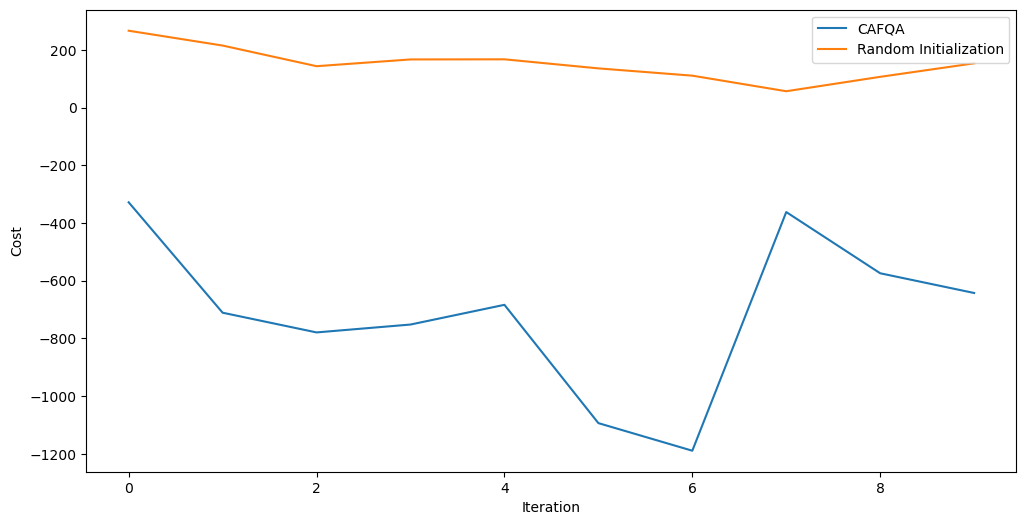

In [20]:
plt.figure(figsize=(12, 6))
plt.plot(cafqa_iteration_vals, label="CAFQA")
plt.plot(random_iteration_vals, label="Random Initialization")
plt.legend()
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()